In [1]:
file_read = "010_fit_int0"
file_write = "011_RMSE_int0"

In [2]:
import polars as pl

df_train_val_preds = pl.read_parquet(f"{file_read}_train_val_preds.parquet")
df_test_preds = pl.read_parquet(f"{file_read}_test_preds.parquet")
df_coefs = pl.read_parquet(f"{file_read}_coefs.parquet")

In [3]:
column_target = "beta_av"
column_target_scaled = "beta_av_logit"
column_pred = f"{column_target}_pred"
column_pred_scaled = f"{column_target_scaled}_pred"

In [4]:
df_train_val_preds = df_train_val_preds.with_columns(
    (100 / (1 + (-pl.col(column_target_scaled)).exp())).alias(column_target),
    (100 / (1 + (-pl.col(column_pred_scaled)).exp())).alias(column_pred),
)

In [5]:
df_train_val_preds

pyridone_test,n_features,pyridone,backbone,beta_av_logit,beta_av_logit_pred,beta_av,beta_av_pred
i32,i32,i64,i64,f64,f64,f64,f64
0,1,1,0,0.56851,-0.034418,63.841924,49.139631
0,1,1,1,0.577178,-0.029241,64.041771,49.269034
0,1,1,2,0.53889,-0.013711,63.155406,49.65724
0,1,1,3,0.85113,-0.018887,70.080418,49.527832
0,1,1,4,0.637598,-0.013711,65.421028,49.657238
…,…,…,…,…,…,…,…
12,1,11,3,-0.486342,-0.093832,38.07556,47.655914
12,1,11,4,-0.441697,-0.088894,39.133657,47.779105
12,1,11,5,0.134649,-0.074686,53.361149,48.133711


In [6]:
df_train_val_rmse = (
    df_train_val_preds
    .group_by("n_features", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_rmse")
    )
)

In [7]:
df_train_val_rmse

n_features,beta_av_rmse
i32,f64
1,11.435405


In [8]:
df_train_val_rmse_min = df_train_val_rmse.filter(
    pl.col(f"{column_target}_rmse") == pl.col(f"{column_target}_rmse").min()
)

In [9]:
df_train_val_rmse_min

n_features,beta_av_rmse
i32,f64
1,11.435405


In [10]:
n_features_min = df_train_val_rmse_min["n_features"][0]

In [11]:
df_test_preds = df_test_preds.with_columns(
    (100 / (1 + (-pl.col(column_target_scaled)).exp())).alias(column_target),
    (100 / (1 + (-pl.col(column_pred_scaled)).exp())).alias(column_pred),
)

In [12]:
df_test_preds

pyridone_test,n_features,backbone,beta_av_logit,beta_av_logit_pred,beta_av,beta_av_pred
i32,i32,i64,f64,f64,f64,f64
0,1,0,0.055549,-0.155508,51.388357,46.120104
0,1,1,0.061619,-0.150331,51.539999,46.248786
0,1,2,-0.086761,-0.134801,47.832328,46.635071
0,1,3,-0.086245,-0.139978,47.845209,46.506263
0,1,4,-0.242775,-0.134801,43.960253,46.635069
…,…,…,…,…,…,…
12,1,3,-0.155744,-0.118047,46.114252,47.05224
12,1,4,-0.010116,-0.113109,49.74711,47.175276
12,1,5,-0.04161,-0.098901,48.959898,47.529479


In [13]:
df_test_rmse = (
    df_test_preds
    .group_by("n_features", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_rmse")
    )
)

In [14]:
df_test_rmse

n_features,beta_av_rmse
i32,f64
1,12.058692


In [15]:
df_test_rmse_min = df_test_rmse.filter(pl.col("n_features") == n_features_min)

In [16]:
df_test_rmse_min

n_features,beta_av_rmse
i32,f64
1,12.058692


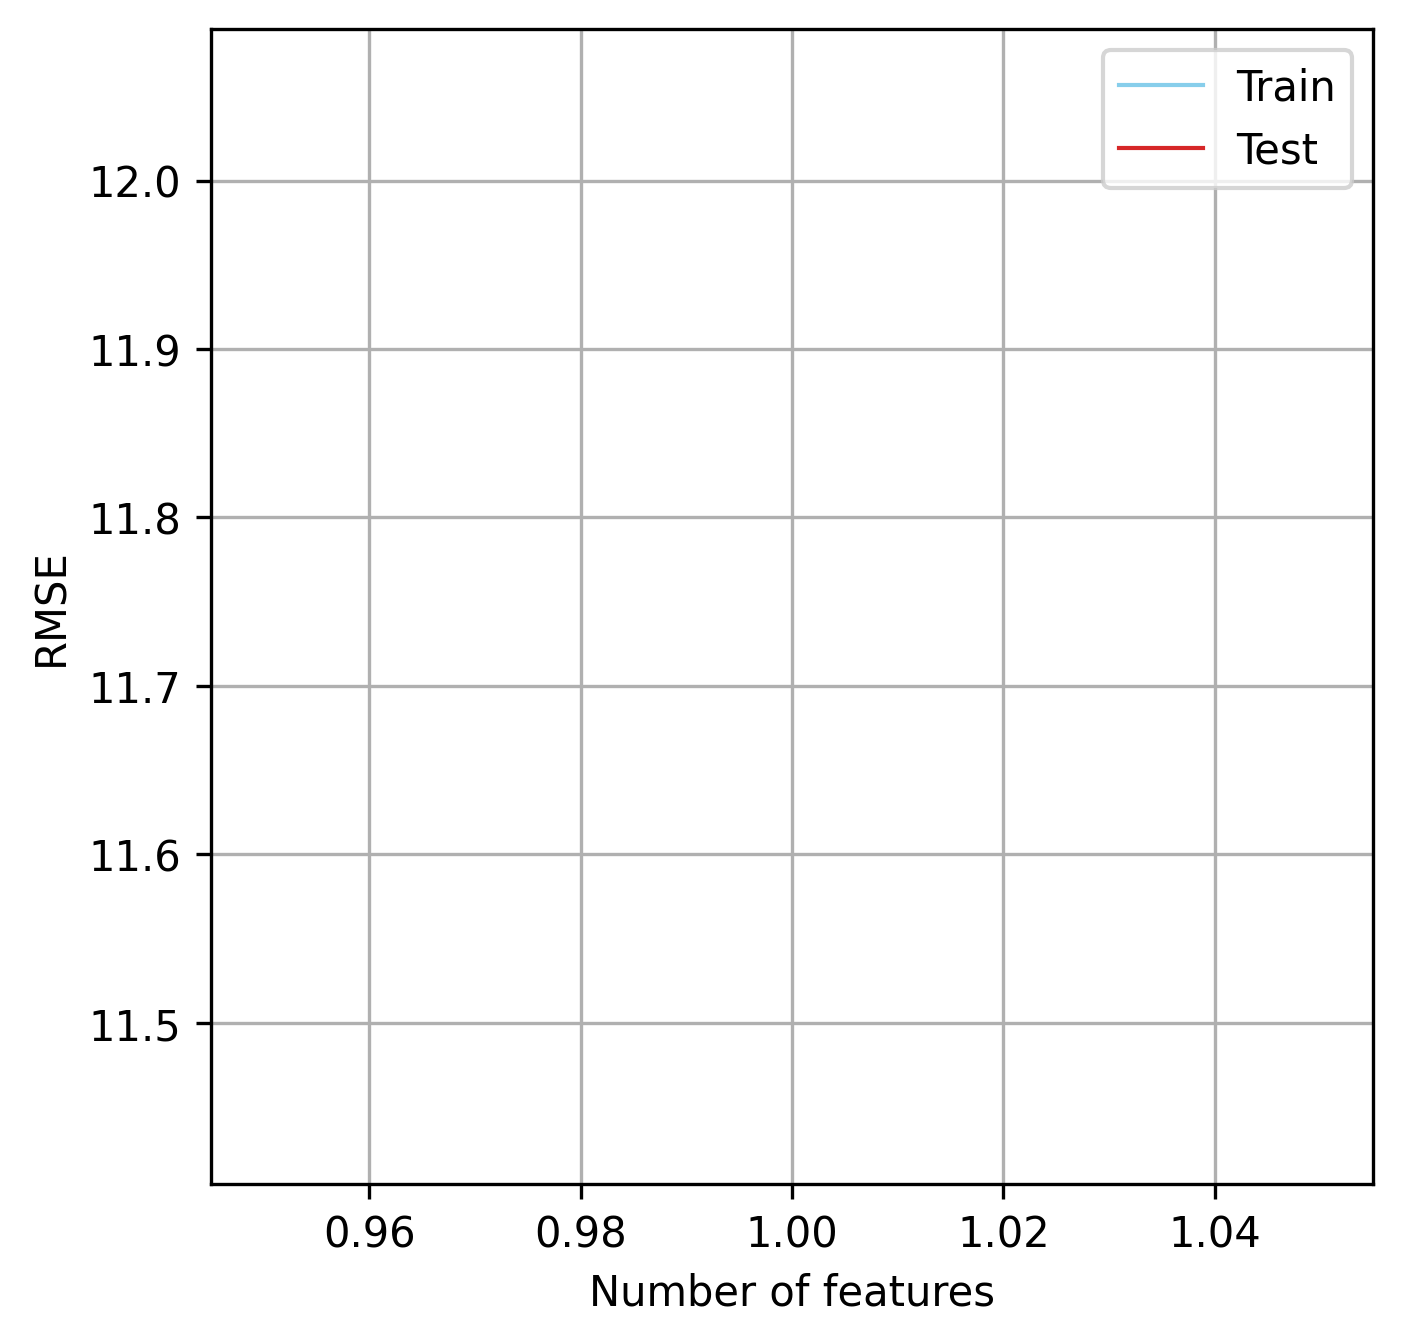

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

ax.plot(
    df_train_val_rmse["n_features"],
    df_train_val_rmse[f"{column_target}_rmse"],
    c="skyblue",
    label="Train",
    lw=1
)
ax.plot(
    df_test_rmse["n_features"],
    df_test_rmse[f"{column_target}_rmse"],
    c="tab:red",
    label="Test",
    lw=1
)

ax.set_xlabel("Number of features")
ax.set_ylabel("RMSE")

ax.grid()
ax.legend()

plt.savefig(
    f"{file_write}_plot.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()

In [18]:
df_train_val_min = df_train_val_preds.filter(pl.col("n_features") == n_features_min)

In [19]:
df_train_val_min

pyridone_test,n_features,pyridone,backbone,beta_av_logit,beta_av_logit_pred,beta_av,beta_av_pred
i32,i32,i64,i64,f64,f64,f64,f64
0,1,1,0,0.56851,-0.034418,63.841924,49.139631
0,1,1,1,0.577178,-0.029241,64.041771,49.269034
0,1,1,2,0.53889,-0.013711,63.155406,49.65724
0,1,1,3,0.85113,-0.018887,70.080418,49.527832
0,1,1,4,0.637598,-0.013711,65.421028,49.657238
…,…,…,…,…,…,…,…
12,1,11,3,-0.486342,-0.093832,38.07556,47.655914
12,1,11,4,-0.441697,-0.088894,39.133657,47.779105
12,1,11,5,0.134649,-0.074686,53.361149,48.133711


In [20]:
df_test_min = df_test_preds.filter(pl.col("n_features") == n_features_min)

In [21]:
df_test_min

pyridone_test,n_features,backbone,beta_av_logit,beta_av_logit_pred,beta_av,beta_av_pred
i32,i32,i64,f64,f64,f64,f64
0,1,0,0.055549,-0.155508,51.388357,46.120104
0,1,1,0.061619,-0.150331,51.539999,46.248786
0,1,2,-0.086761,-0.134801,47.832328,46.635071
0,1,3,-0.086245,-0.139978,47.845209,46.506263
0,1,4,-0.242775,-0.134801,43.960253,46.635069
…,…,…,…,…,…,…
12,1,3,-0.155744,-0.118047,46.114252,47.05224
12,1,4,-0.010116,-0.113109,49.74711,47.175276
12,1,5,-0.04161,-0.098901,48.959898,47.529479


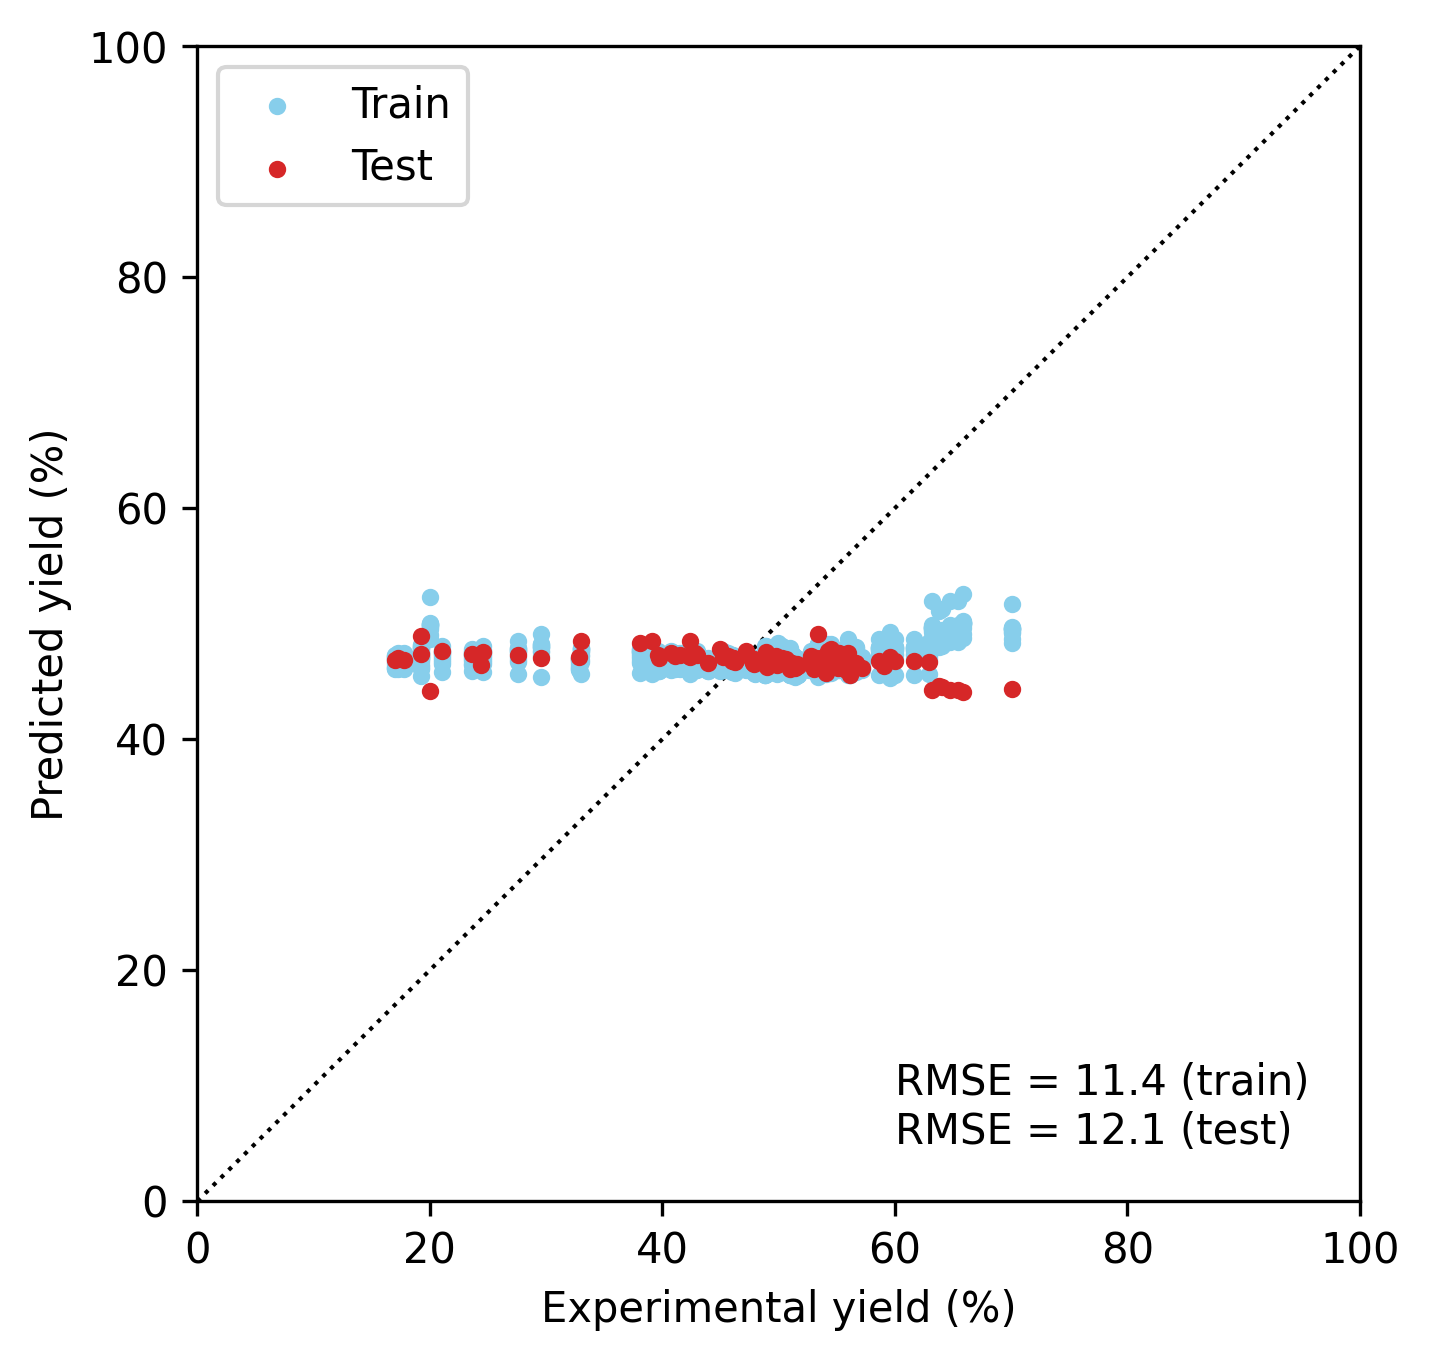

In [22]:
fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

ax.plot(
    [0, 100],
    [0, 100],
    c="black",
    linestyle="dotted",
    lw=1,
    zorder=0
)
ax.scatter(
    df_train_val_min[column_target],
    df_train_val_min[column_pred],
    c="skyblue",
    label="Train",
    s=10,
    zorder=1
)
ax.scatter(
    df_test_min[column_target],
    df_test_min[column_pred],
    c="tab:red",
    label="Test",
    s=10,
    zorder=2
)

ax.set_xlabel("Experimental yield (%)")
ax.set_ylabel("Predicted yield (%)")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

ax.legend()
ax.text(
    0.60, 0.05,
    f"RMSE = {df_train_val_rmse_min[f'{column_target}_rmse'][0]:1.1f} (train)\n"
    f"RMSE = {df_test_rmse_min[f'{column_target}_rmse'][0]:1.1f} (test)",
    transform=ax.transAxes
)

plt.savefig(
    f"{file_write}_scatter_all.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()

In [23]:
column_group = "pyridone"

In [24]:
groups_test = df_test_preds[f"{column_group}_test"].unique(maintain_order=True)

In [25]:
groups_test

pyridone_test
i32
0
1
2
3
4
…
8
9
10


In [26]:
df_train_val_min

pyridone_test,n_features,pyridone,backbone,beta_av_logit,beta_av_logit_pred,beta_av,beta_av_pred
i32,i32,i64,i64,f64,f64,f64,f64
0,1,1,0,0.56851,-0.034418,63.841924,49.139631
0,1,1,1,0.577178,-0.029241,64.041771,49.269034
0,1,1,2,0.53889,-0.013711,63.155406,49.65724
0,1,1,3,0.85113,-0.018887,70.080418,49.527832
0,1,1,4,0.637598,-0.013711,65.421028,49.657238
…,…,…,…,…,…,…,…
12,1,11,3,-0.486342,-0.093832,38.07556,47.655914
12,1,11,4,-0.441697,-0.088894,39.133657,47.779105
12,1,11,5,0.134649,-0.074686,53.361149,48.133711


In [27]:
df_train_val_min_rmse = (
    df_train_val_min
    .group_by(f"{column_group}_test", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_rmse")
    )
)

In [28]:
df_train_val_min_rmse

pyridone_test,beta_av_rmse
i32,f64
0,11.465305
1,10.629189
2,11.309302
3,11.742579
4,11.645059
…,…
8,11.415968
9,11.609963
10,11.526257


In [29]:
df_test_min_rmse = (
    df_test_min
    .group_by(f"{column_group}_test", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_rmse")
    )
)

In [30]:
df_test_min_rmse

pyridone_test,beta_av_rmse
i32,f64
0,11.240153
1,21.466963
2,13.797543
3,7.968152
4,8.9874
…,…
8,11.94278
9,9.295308
10,10.480947


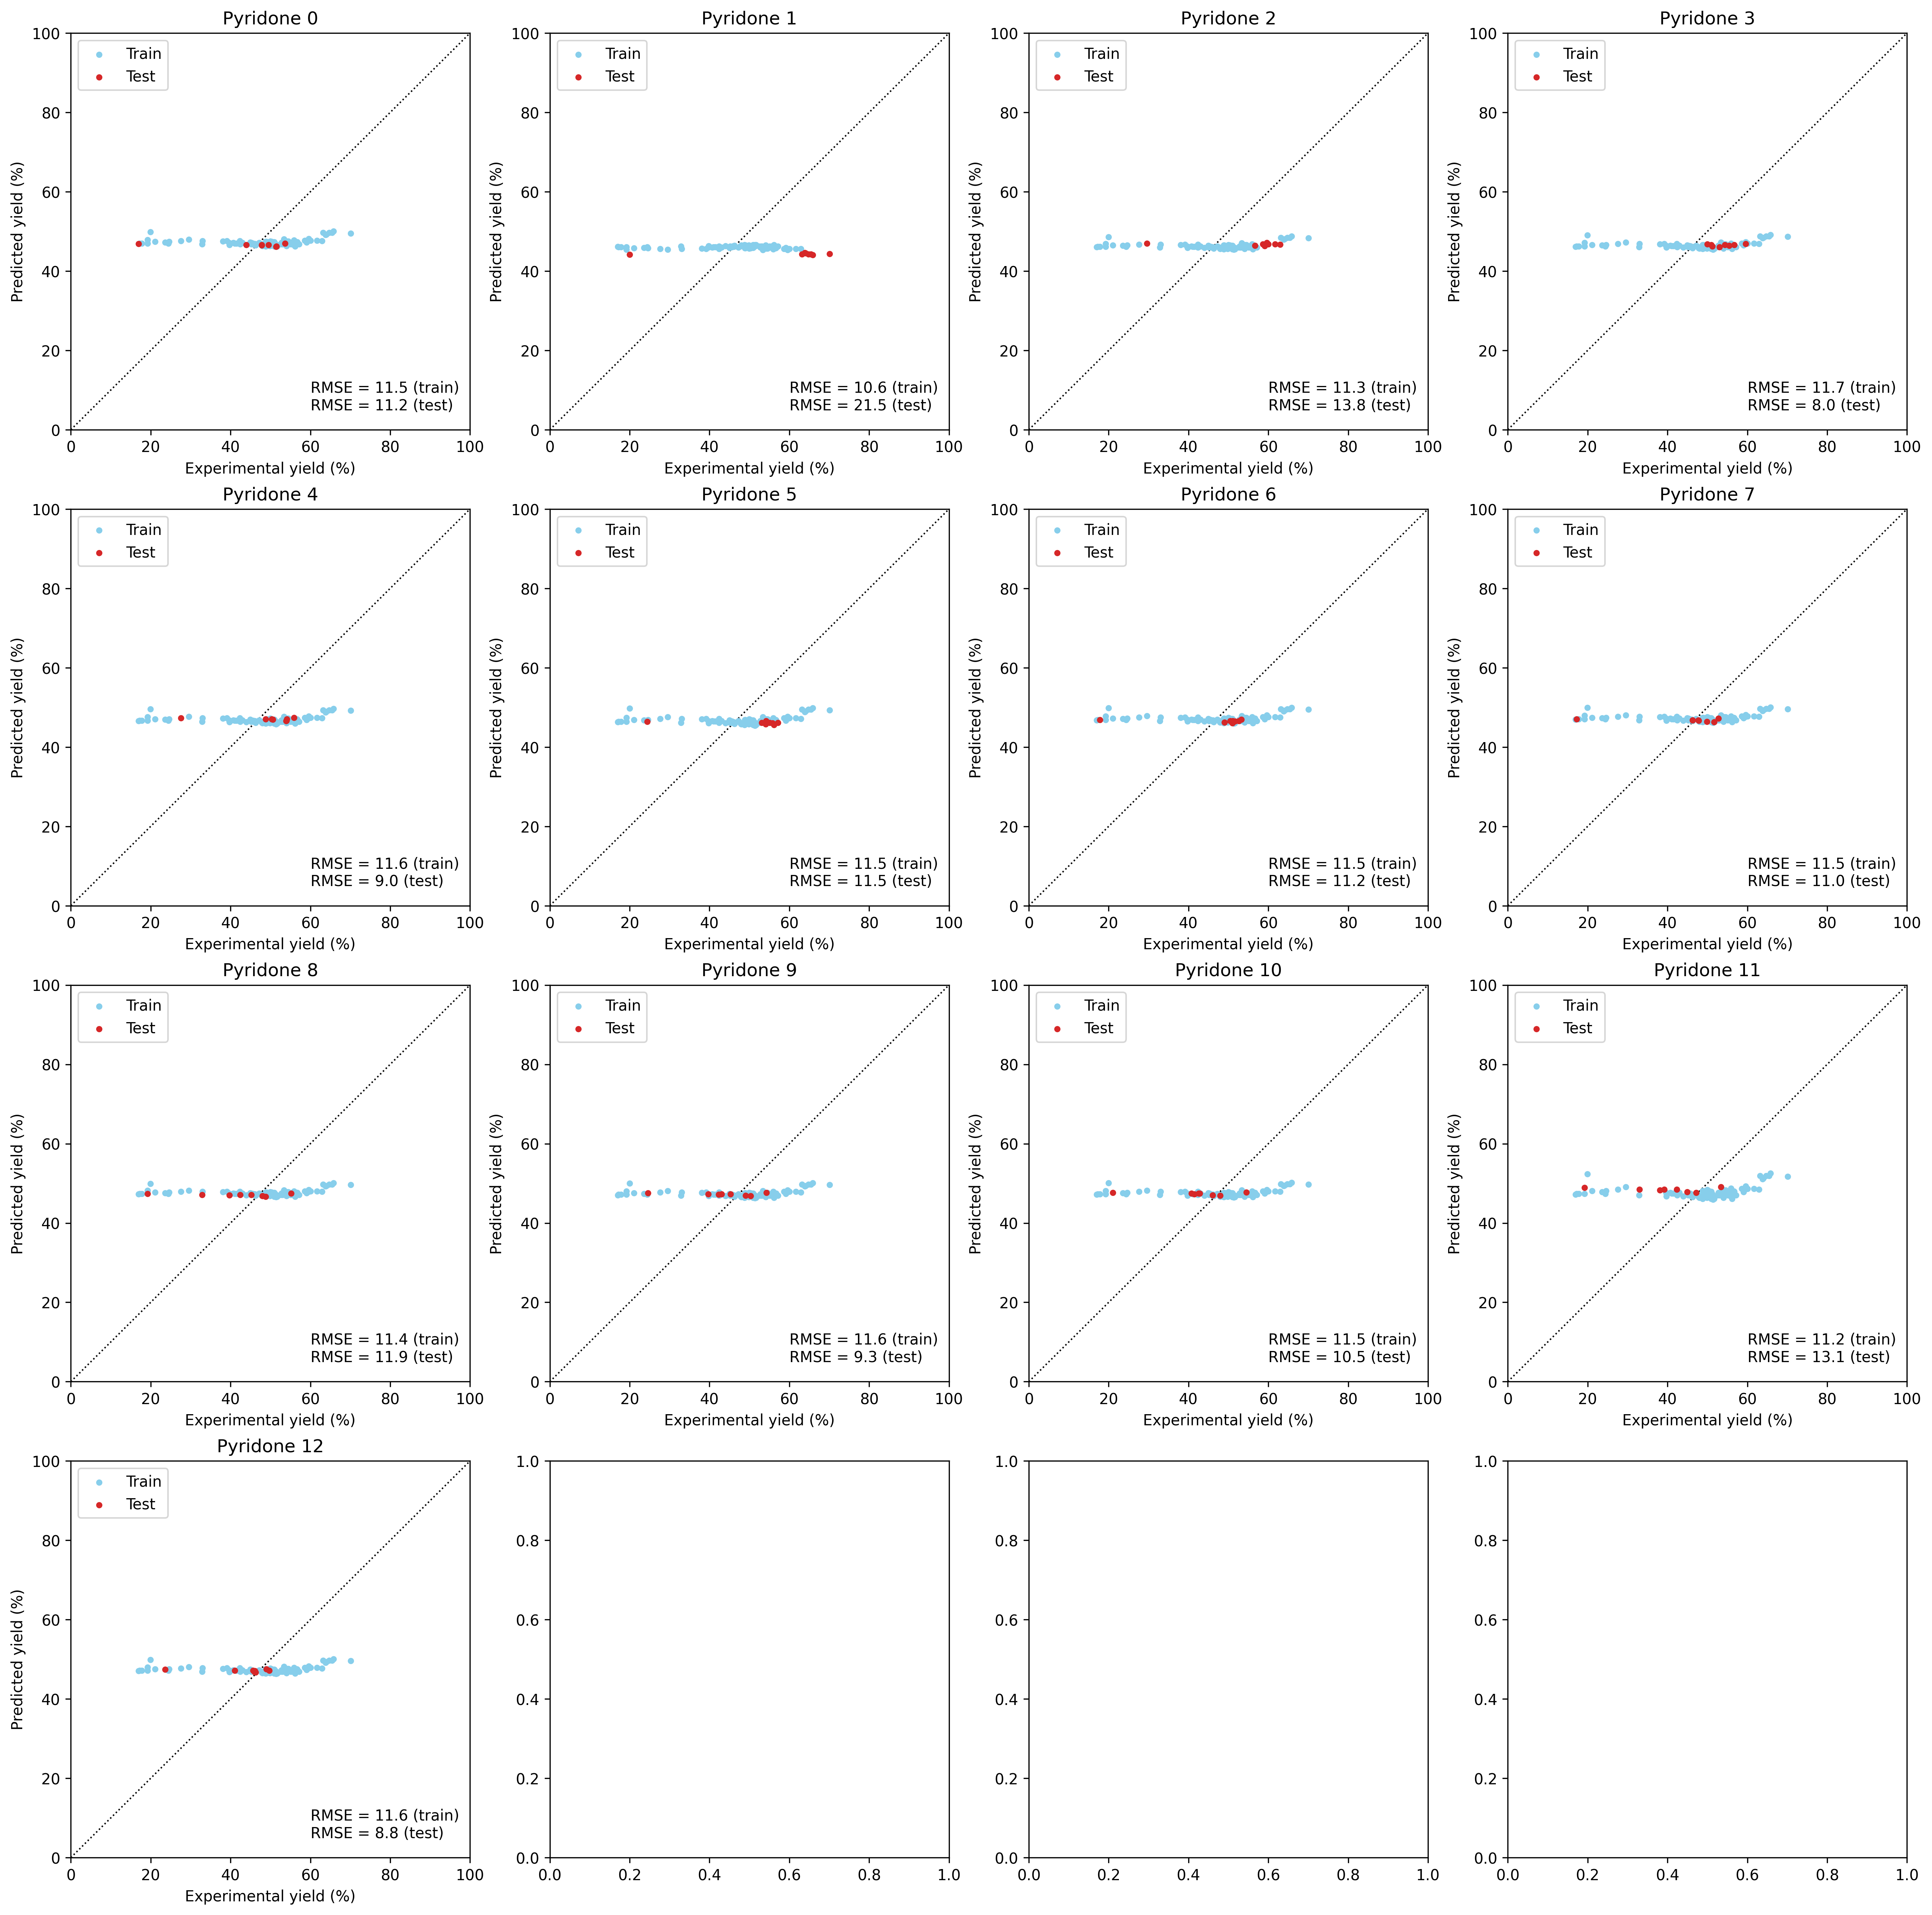

In [31]:
fig, axes = plt.subplots(4, 4, figsize=(22, 22), dpi=300)

for group_test in groups_test:
    df_train_val_min_ = df_train_val_min.filter(pl.col(f'{column_group}_test') == group_test)
    df_test_min_ = df_test_min.filter(pl.col(f'{column_group}_test') == group_test)
    df_train_val_min_rmse_ = df_train_val_min_rmse.filter(pl.col(f'{column_group}_test') == group_test)
    df_test_min_rmse_ = df_test_min_rmse.filter(pl.col(f'{column_group}_test') == group_test)
    
    div, mod = divmod(group_test, 4)
    
    axes[div, mod].plot(
        [0, 100],
        [0, 100],
        c="black",
        linestyle="dotted",
        lw=1,
        zorder=0
    )
    axes[div, mod].scatter(
        df_train_val_min_[column_target],
        df_train_val_min_[column_pred],
        c="skyblue",
        s=10,
        label="Train",
        zorder=1
    )
    axes[div, mod].scatter(
        df_test_min_[column_target],
        df_test_min_[column_pred],
        c="tab:red",
        s=10,
        label="Test",
        zorder=2
    )
    
    axes[div, mod].set_title(f"Pyridone {group_test}")
    axes[div, mod].set_xlabel("Experimental yield (%)")
    axes[div, mod].set_ylabel("Predicted yield (%)")
    axes[div, mod].set_xlim(0, 100)
    axes[div, mod].set_ylim(0, 100)
    
    axes[div, mod].legend()
    axes[div, mod].text(
        0.60, 0.05,
        f"RMSE = {df_train_val_min_rmse_[f'{column_target}_rmse'][0]:1.1f} (train)\n"
        f"RMSE = {df_test_min_rmse_[f'{column_target}_rmse'][0]:1.1f} (test)",
        transform=axes[div, mod].transAxes
    )
    
plt.savefig(
    f"{file_write}_scatter_each.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()